## 📊 VÒNG 1: DESCRIPTIVE — ĐỐI SOÁT DOANH THU THEO CA

**Mục tiêu:**
- Ghép `DetailsTransaction` vào từng ca trong `MainLog` theo cửa sổ thời gian
- Tính `Payment_Mismatch` (lệch đối soát bill) và `Cash_Diff` (lệch két)
- EDA phân phối sai lệch theo ca, theo thời gian
- Xuất `df_audit` sạch làm đầu vào cho Vòng 2 (Clustering)

**Output:** `data/Audit_Merged_Data.csv`

---
## 0. Import & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- Style chuẩn cho toàn bộ notebook ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Helper format số VNĐ
def fmt_vnd(x):
    return f"{x:,.0f} đ"

print("✅ Đã load thư viện thành công.")

✅ Đã load thư viện thành công.


---
## 1. Load Data & Data Understanding

In [2]:
df_details = pd.read_csv('./data/DetailsTransaction.csv')
df_main    = pd.read_csv('./data/MainLog.csv')

print(f"DetailsTransaction: {df_details.shape[0]:,} dòng, {df_details.shape[1]} cột")
print(f"MainLog:            {df_main.shape[0]:,} dòng, {df_main.shape[1]} cột")

DetailsTransaction: 5,412 dòng, 5 cột
MainLog:            242 dòng, 6 cột


In [3]:
print("=== DetailsTransaction — 5 dòng đầu ===")
display(df_details.head())
print("\n=== DetailsTransaction — Thống kê cơ bản ===")
display(df_details.describe(include='all'))

=== DetailsTransaction — 5 dòng đầu ===


,transaction_at,total_revenue,transfer_payment,cash_payment,notes
0,12/20/2025 7:05:54,19000,0,19000,NaN
1,12/20/2025 7:42:26,19000,0,19000,NaN
2,12/20/2025 7:51:58,38000,0,38000,NaN
3,12/20/2025 7:52:09,66000,0,66000,NaN
4,12/20/2025 7:52:41,22000,0,22000,NaN



=== DetailsTransaction — Thống kê cơ bản ===


,transaction_at,total_revenue,transfer_payment,cash_payment,notes
count,5412,5412.000000,5412.000000,5412.000000,101
unique,5412,NaN,NaN,NaN,45
top,4/30/2026 15:53:54,NaN,NaN,NaN,ngoc pt
freq,1,NaN,NaN,NaN,31
mean,NaN,35383.407243,16803.215078,18578.713969,NaN
std,NaN,29483.389727,29737.667244,24681.506510,NaN
min,NaN,10000.000000,0.000000,0.000000,NaN
25%,NaN,20000.000000,0.000000,0.000000,NaN
50%,NaN,23000.000000,0.000000,19000.000000,NaN
75%,NaN,43000.000000,23000.000000,23000.000000,NaN


In [4]:
print("=== MainLog — 5 dòng đầu ===")
display(df_main.head())
print("\n=== MainLog — Thống kê cơ bản ===")
display(df_main.describe(include='all'))

=== MainLog — 5 dòng đầu ===


,timestamp,total_revenue,transfer_amount,cash_amount,is_morning_shift,actual_cash_in_drawer
0,12/20/2025 7:04:51,0,0,0,True,1240000
1,12/20/2025 11:53:49,867000,332000,535000,True,850000
2,12/20/2025 17:54:52,462000,250000,212000,False,860
3,12/21/2025 11:45:24,544000,126000,418000,True,490
4,12/21/2025 17:01:43,488000,166000,322000,False,840000



=== MainLog — Thống kê cơ bản ===


,timestamp,total_revenue,transfer_amount,cash_amount,is_morning_shift,actual_cash_in_drawer
count,242,2.420000e+02,2.420000e+02,2.420000e+02,242,2.420000e+02
unique,242,NaN,NaN,NaN,2,NaN
top,12/20/2025 7:04:51,NaN,NaN,NaN,False,NaN
freq,1,NaN,NaN,NaN,128,NaN
mean,NaN,7.913017e+05,3.757810e+05,4.154876e+05,NaN,1.210737e+06
std,NaN,3.493372e+05,2.028272e+05,2.272818e+05,NaN,5.257573e+05
min,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00
25%,NaN,6.210000e+05,2.492500e+05,2.300000e+05,NaN,8.700000e+05
50%,NaN,7.710000e+05,3.660000e+05,4.070000e+05,NaN,1.185000e+06
75%,NaN,9.475000e+05,4.695000e+05,5.597500e+05,NaN,1.530000e+06


**Ghi chú cấu trúc dữ liệu:**

| Bảng | Cột thời gian | Vai trò |
|---|---|---|
| `MainLog` | `timestamp` | Thời điểm **chốt ca** (snapshot cuối ca) |
| `DetailsTransaction` | `transaction_at` | Thời điểm **từng hóa đơn** |

Mỗi ca trong `MainLog` có 2 dòng: dòng **mở ca** (revenue=0) và dòng **chốt ca** (revenue>0).  
Ta sẽ dùng cửa sổ `(timestamp_chốt_ca_trước, timestamp_chốt_ca_này]` để gộp hóa đơn.

---
## 2. Preprocessing — Chuẩn hóa Thời gian & Lọc Dữ liệu

In [5]:
# Ép kiểu datetime
df_details['transaction_at'] = pd.to_datetime(df_details['transaction_at'], dayfirst=False)
df_main['timestamp']         = pd.to_datetime(df_main['timestamp'], dayfirst=False)

# Sắp xếp tăng dần
df_details = df_details.sort_values('transaction_at').reset_index(drop=True)
df_main    = df_main.sort_values('timestamp').reset_index(drop=True)

print(f"Details: {df_details['transaction_at'].min()} → {df_details['transaction_at'].max()}")
print(f"MainLog: {df_main['timestamp'].min()} → {df_main['timestamp'].max()}")

Details: 2025-12-20 07:05:54 → 2026-04-30 15:53:54
MainLog: 2025-12-20 07:04:51 → 2026-04-30 16:18:32


In [6]:
# Tách ca thực sự (có doanh thu > 0) — loại bỏ dòng mở ca (revenue=0)
# Dòng revenue=0 chỉ là checkpoint mở ca, không phải ca chốt sổ
df_shifts = df_main[df_main['total_revenue'] > 0].copy().reset_index(drop=True)

print(f"Số ca thực sự (có doanh thu): {len(df_shifts)}")
print(f"Số dòng mở ca bị loại: {len(df_main) - len(df_shifts)}")
display(df_shifts.head(3))

Số ca thực sự (có doanh thu): 236
Số dòng mở ca bị loại: 6


,timestamp,total_revenue,transfer_amount,cash_amount,is_morning_shift,actual_cash_in_drawer
0,2025-12-20 11:53:49,867000,332000,535000,True,850000
1,2025-12-20 17:54:52,462000,250000,212000,False,860
2,2025-12-21 11:45:24,544000,126000,418000,True,490


---
## 3. Aggregation — Ghép Hóa đơn vào Từng Ca (Window-based Join)

In [7]:
# Thuật toán: Dùng merge_asof + groupby theo shift_id
# Gán mỗi hóa đơn vào ca gần nhất SAU nó trong danh sách chốt ca

# Tạo bản sao để assign
details = df_details.copy()
shifts  = df_shifts.copy().reset_index().rename(columns={'index': 'shift_id'})

# merge_asof: mỗi hóa đơn khớp với ca chốt gần nhất (direction='forward')
# => hóa đơn sẽ gán cho ca chốt CÓ timestamp >= transaction_at
details_sorted = details.sort_values('transaction_at')
shifts_sorted  = shifts.sort_values('timestamp')

merged = pd.merge_asof(
    details_sorted,
    shifts_sorted[['shift_id', 'timestamp']],
    left_on='transaction_at',
    right_on='timestamp',
    direction='forward'   # mỗi bill ghép vào ca chốt NGAY SAU NÓ
)

# Hóa đơn sau ca chốt cuối cùng sẽ có shift_id=NaN → bỏ qua
n_unmatched = merged['shift_id'].isna().sum()
print(f"Hóa đơn không khớp ca nào (sau ca chốt cuối): {n_unmatched}")
merged = merged.dropna(subset=['shift_id'])
merged['shift_id'] = merged['shift_id'].astype(int)

print(f"Hóa đơn đã ghép ca: {len(merged):,}")

Hóa đơn không khớp ca nào (sau ca chốt cuối): 0
Hóa đơn đã ghép ca: 5,412


In [8]:
# Aggregate: tính tổng tiền mặt, chuyển khoản, số bill theo từng ca
agg = merged.groupby('shift_id').agg(
    detail_cash_sum      = ('cash_payment', 'sum'),
    detail_transfer_sum  = ('transfer_payment', 'sum'),
    detail_revenue_sum   = ('total_revenue', 'sum'),
    bill_count           = ('total_revenue', 'count'),
).reset_index()

# Merge vào df_shifts
df_audit = shifts.merge(agg, on='shift_id', how='left')
df_audit[['detail_cash_sum','detail_transfer_sum','detail_revenue_sum','bill_count']] = \
    df_audit[['detail_cash_sum','detail_transfer_sum','detail_revenue_sum','bill_count']].fillna(0)

print(f"df_audit: {df_audit.shape[0]} ca — Sample:")
display(df_audit[['timestamp','is_morning_shift','total_revenue','bill_count',
                   'detail_cash_sum','detail_transfer_sum']].head(5))

df_audit: 236 ca — Sample:


,timestamp,is_morning_shift,total_revenue,bill_count,detail_cash_sum,detail_transfer_sum
0,2025-12-20 11:53:49,True,867000,27,535000,332000
1,2025-12-20 17:54:52,False,462000,16,212000,250000
2,2025-12-21 11:45:24,True,544000,17,418000,126000
3,2025-12-21 17:01:43,False,488000,13,322000,166000
4,2025-12-22 11:50:31,True,926000,34,551000,375000


---
## 4. Feature Engineering — Trích xuất Đặc trưng Kiểm toán

In [9]:
# ─── Chỉ số lệch cốt lõi ───────────────────────────────────────────────────

# Cash_Diff: Két thực tế - Số tiền mặt máy ghi
# (+) dư két | (0) khớp hoàn toàn | (–) hụt két
df_audit['Cash_Diff'] = df_audit['actual_cash_in_drawer'] - df_audit['cash_amount']

# Payment_Mismatch: Tổng tiền mặt từ bill chi tiết - Số tiền mặt máy chốt
# (+) bill ghi nhiều hơn máy chốt | (–) bill ghi ít hơn
df_audit['Payment_Mismatch'] = df_audit['detail_cash_sum'] - df_audit['cash_amount']

# Revenue_Mismatch: Tổng doanh thu từ bill - Doanh thu máy chốt
# Phát hiện bill chưa bấm vào hệ thống hoặc bấm thừa
df_audit['Revenue_Mismatch'] = df_audit['detail_revenue_sum'] - df_audit['total_revenue']

# ─── Chỉ số tốc độ & tỷ lệ ─────────────────────────────────────────────────

# Cash_Ratio: Tỷ lệ tiền mặt trong tổng doanh thu
df_audit['Cash_Ratio'] = np.where(
    df_audit['total_revenue'] > 0,
    df_audit['cash_amount'] / df_audit['total_revenue'],
    0
)

# Shift_Velocity: Số bill / giờ (nếu có thể tính được — dùng bill_count / 8h giả định)
# Sẽ tính chính xác hơn ở Vòng 2, tạm dùng bill_count làm proxy
df_audit['Shift_Velocity'] = df_audit['bill_count']

# ─── Nhãn dễ đọc ───────────────────────────────────────────────────────────
df_audit['Shift_Name'] = df_audit['is_morning_shift'].map({True: 'Ca Sáng', False: 'Ca Chiều'})
df_audit['Date']       = df_audit['timestamp'].dt.date

print("Các feature kiểm toán đã được tạo:")
display(df_audit[['Cash_Diff','Payment_Mismatch','Revenue_Mismatch','Cash_Ratio','bill_count']].describe().round(0))

Các feature kiểm toán đã được tạo:


,Cash_Diff,Payment_Mismatch,Revenue_Mismatch,Cash_Ratio,bill_count
count,236.0,236.0,236.0,236.0,236.0
mean,801739.0,0.0,0.0,1.0,23.0
std,529359.0,0.0,0.0,0.0,9.0
min,-555520.0,0.0,0.0,0.0,3.0
25%,457500.0,0.0,0.0,0.0,17.0
50%,783500.0,0.0,0.0,1.0,22.0
75%,1094500.0,0.0,0.0,1.0,28.0
max,2272000.0,0.0,0.0,1.0,53.0


In [10]:
# Kiểm tra nhanh: tỷ lệ ca có sai lệch
n_total  = len(df_audit)
n_cash_gap    = (df_audit['Cash_Diff'].abs() > 10_000).sum()
n_mismatch    = (df_audit['Payment_Mismatch'].abs() > 10_000).sum()
n_rev_gap     = (df_audit['Revenue_Mismatch'].abs() > 10_000).sum()

print(f"Tổng số ca: {n_total}")
print(f"Ca lệch két (|Cash_Diff| > 10k):          {n_cash_gap:3d} ({n_cash_gap/n_total:.0%})")
print(f"Ca lệch đối soát bill (|Mismatch| > 10k): {n_mismatch:3d} ({n_mismatch/n_total:.0%})")
print(f"Ca lệch doanh thu tổng (|Rev_Gap| > 10k): {n_rev_gap:3d} ({n_rev_gap/n_total:.0%})")

Tổng số ca: 236
Ca lệch két (|Cash_Diff| > 10k):          235 (100%)
Ca lệch đối soát bill (|Mismatch| > 10k):   0 (0%)
Ca lệch doanh thu tổng (|Rev_Gap| > 10k):   0 (0%)


---
## 5. EDA — Phân phối Sai lệch (Cash_Diff & Payment_Mismatch)

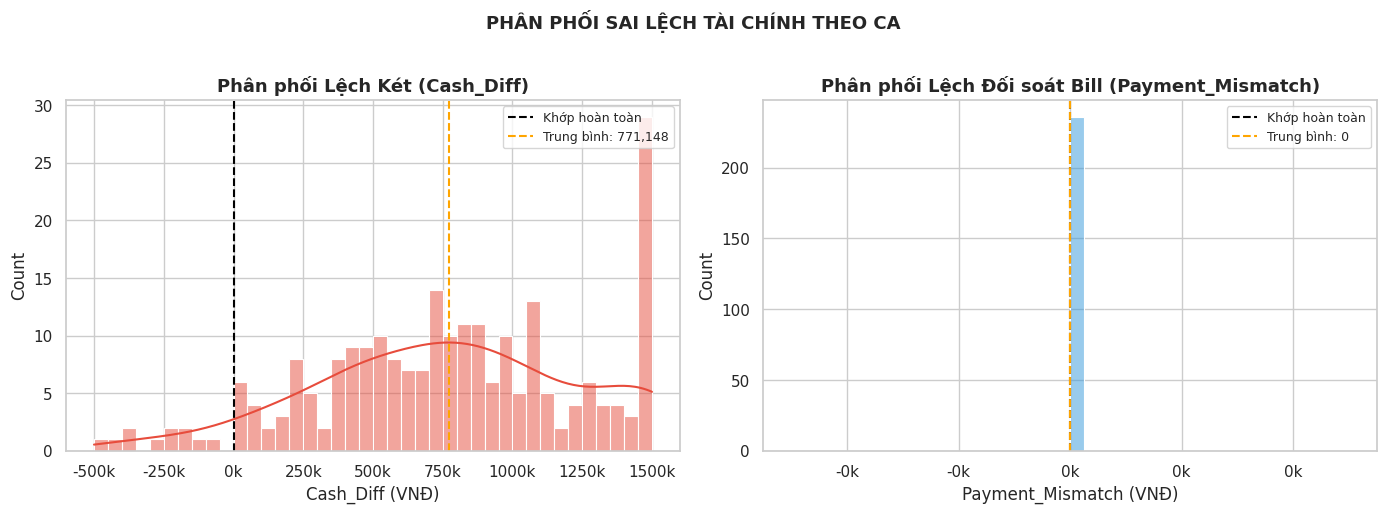


📌 Ghi chú: Trục X đã được clip để loại bỏ outlier cực đoan cho dễ đọc.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram Cash_Diff ---
ax = axes[0]
data_cd = df_audit['Cash_Diff'].clip(-500_000, 1_500_000)
sns.histplot(data_cd, bins=40, kde=True, color='#e74c3c', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Khớp hoàn toàn')
ax.axvline(data_cd.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Trung bình: {data_cd.mean():,.0f}')
ax.set_title('Phân phối Lệch Két (Cash_Diff)')
ax.set_xlabel('Cash_Diff (VNĐ)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(fontsize=9)

# --- Histogram Payment_Mismatch ---
ax = axes[1]
data_pm = df_audit['Payment_Mismatch'].clip(-300_000, 300_000)
sns.histplot(data_pm, bins=40, kde=True, color='#3498db', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Khớp hoàn toàn')
ax.axvline(data_pm.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Trung bình: {data_pm.mean():,.0f}')
ax.set_title('Phân phối Lệch Đối soát Bill (Payment_Mismatch)')
ax.set_xlabel('Payment_Mismatch (VNĐ)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(fontsize=9)

plt.suptitle('PHÂN PHỐI SAI LỆCH TÀI CHÍNH THEO CA', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Ghi chú: Trục X đã được clip để loại bỏ outlier cực đoan cho dễ đọc.")

---
## 6. EDA — So sánh Ca Sáng vs Ca Chiều

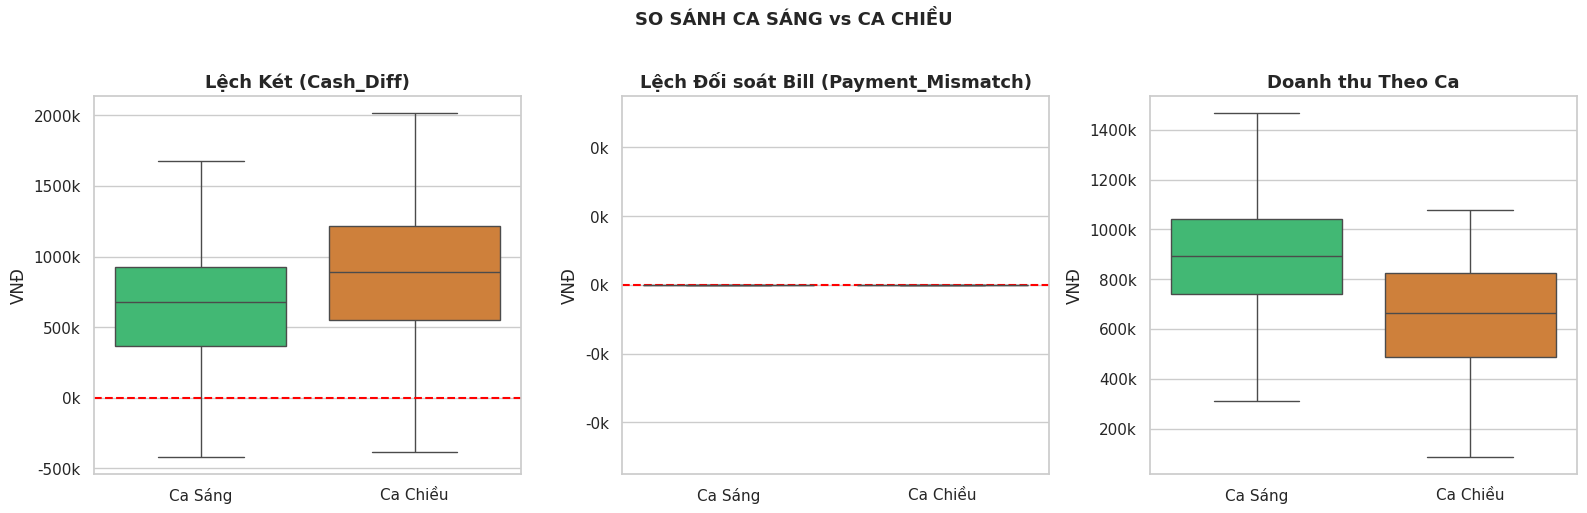

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = {'Ca Sáng': '#2ecc71', 'Ca Chiều': '#e67e22'}

# Boxplot Cash_Diff
sns.boxplot(data=df_audit, x='Shift_Name', y='Cash_Diff',
            palette=palette, ax=axes[0], showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Lệch Két (Cash_Diff)')
axes[0].set_ylabel('VNĐ')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[0].set_xlabel('')

# Boxplot Payment_Mismatch
sns.boxplot(data=df_audit, x='Shift_Name', y='Payment_Mismatch',
            palette=palette, ax=axes[1], showfliers=False)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Lệch Đối soát Bill (Payment_Mismatch)')
axes[1].set_ylabel('VNĐ')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[1].set_xlabel('')

# Boxplot Doanh thu
sns.boxplot(data=df_audit, x='Shift_Name', y='total_revenue',
            palette=palette, ax=axes[2], showfliers=False)
axes[2].set_title('Doanh thu Theo Ca')
axes[2].set_ylabel('VNĐ')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[2].set_xlabel('')

plt.suptitle('SO SÁNH CA SÁNG vs CA CHIỀU', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Thống kê trung bình theo ca
summary_shift = df_audit.groupby('Shift_Name').agg(
    So_ca          = ('shift_id', 'count'),
    DT_TB          = ('total_revenue', 'mean'),
    Cash_Diff_TB   = ('Cash_Diff', 'mean'),
    Mismatch_TB    = ('Payment_Mismatch', 'mean'),
    Cash_Ratio_TB  = ('Cash_Ratio', 'mean'),
    Bill_TB        = ('bill_count', 'mean'),
).round(0)

print("Thống kê trung bình theo loại ca:")
display(summary_shift)

Thống kê trung bình theo loại ca:


,So_ca,DT_TB,Cash_Diff_TB,Mismatch_TB,Cash_Ratio_TB,Bill_TB
Shift_Name,,,,,,
Ca Chiều,125,720584.0,901395.0,0.0,0.0,20.0
Ca Sáng,111,913712.0,689513.0,0.0,1.0,26.0


---
## 7. EDA — Chuỗi Thời gian Dòng tiền (Time Series)

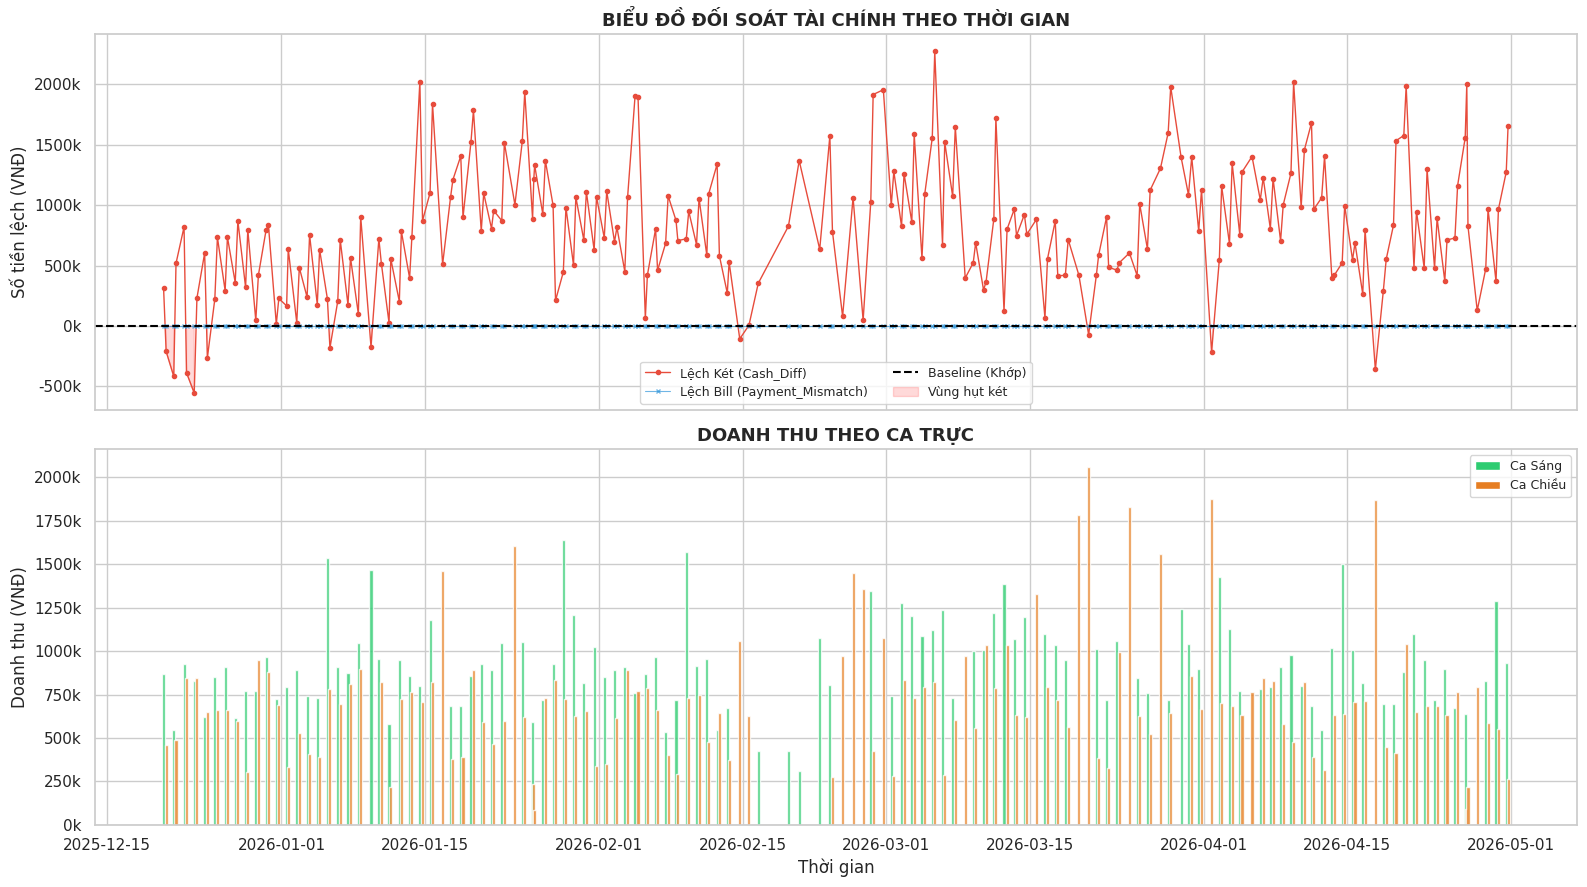

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ── Panel 1: Cash_Diff & Payment_Mismatch ──────────────────────────────────
ax = axes[0]
ax.plot(df_audit['timestamp'], df_audit['Cash_Diff'],
        marker='o', markersize=3, linewidth=1, color='#e74c3c', label='Lệch Két (Cash_Diff)')
ax.plot(df_audit['timestamp'], df_audit['Payment_Mismatch'],
        marker='x', markersize=3, linewidth=0.8, color='#3498db', alpha=0.7,
        label='Lệch Bill (Payment_Mismatch)')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Baseline (Khớp)')

# Tô màu vùng âm (nghi thất thoát)
ax.fill_between(df_audit['timestamp'], df_audit['Cash_Diff'], 0,
                where=(df_audit['Cash_Diff'] < 0), alpha=0.15, color='red',
                label='Vùng hụt két')
ax.set_title('BIỂU ĐỒ ĐỐI SOÁT TÀI CHÍNH THEO THỜI GIAN')
ax.set_ylabel('Số tiền lệch (VNĐ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(fontsize=9, ncol=2)

# ── Panel 2: Doanh thu theo ca ─────────────────────────────────────────────
ax2 = axes[1]
colors = df_audit['Shift_Name'].map({'Ca Sáng': '#2ecc71', 'Ca Chiều': '#e67e22'})
ax2.bar(df_audit['timestamp'], df_audit['total_revenue'],
        color=colors, width=0.3, alpha=0.8)
ax2.set_title('DOANH THU THEO CA TRỰC')
ax2.set_ylabel('Doanh thu (VNĐ)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Legend thủ công
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Ca Sáng'),
                   Patch(facecolor='#e67e22', label='Ca Chiều')]
ax2.legend(handles=legend_elements, fontsize=9)

plt.xlabel('Thời gian')
plt.tight_layout()
plt.show()

---
## 8. EDA — Correlation Heatmap

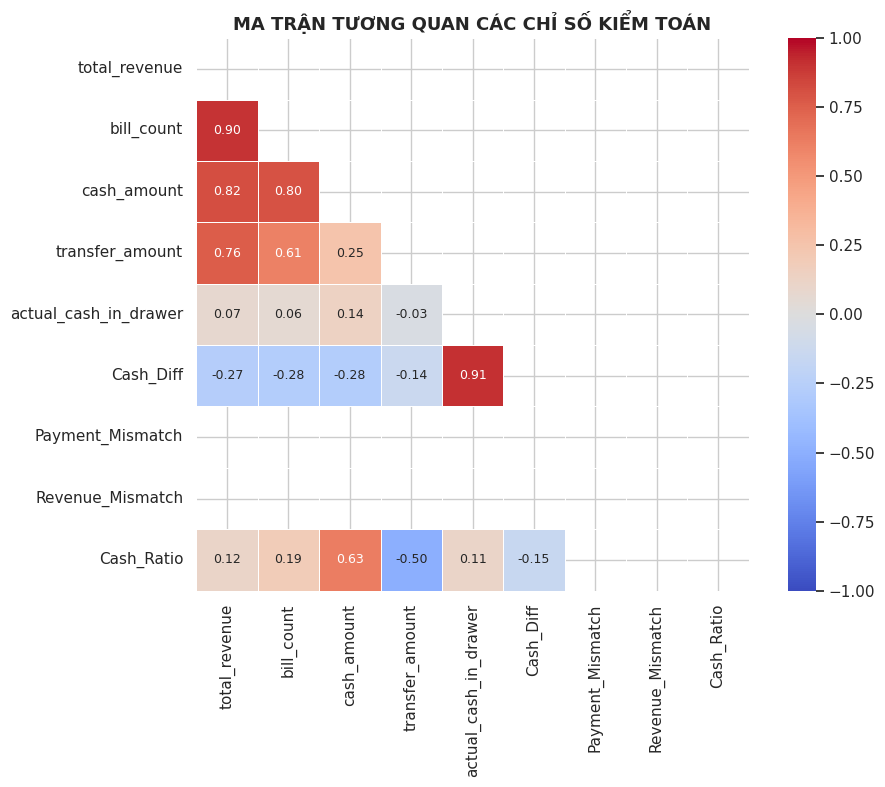

In [15]:
corr_cols = [
    'total_revenue', 'bill_count', 'cash_amount', 'transfer_amount',
    'actual_cash_in_drawer', 'Cash_Diff', 'Payment_Mismatch', 'Revenue_Mismatch', 'Cash_Ratio'
]

corr_matrix = df_audit[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmax=1, vmin=-1, center=0,
    square=True, linewidths=.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('MA TRẬN TƯƠNG QUAN CÁC CHỈ SỐ KIỂM TOÁN', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. EDA — Phương thức Thanh toán tổng quan

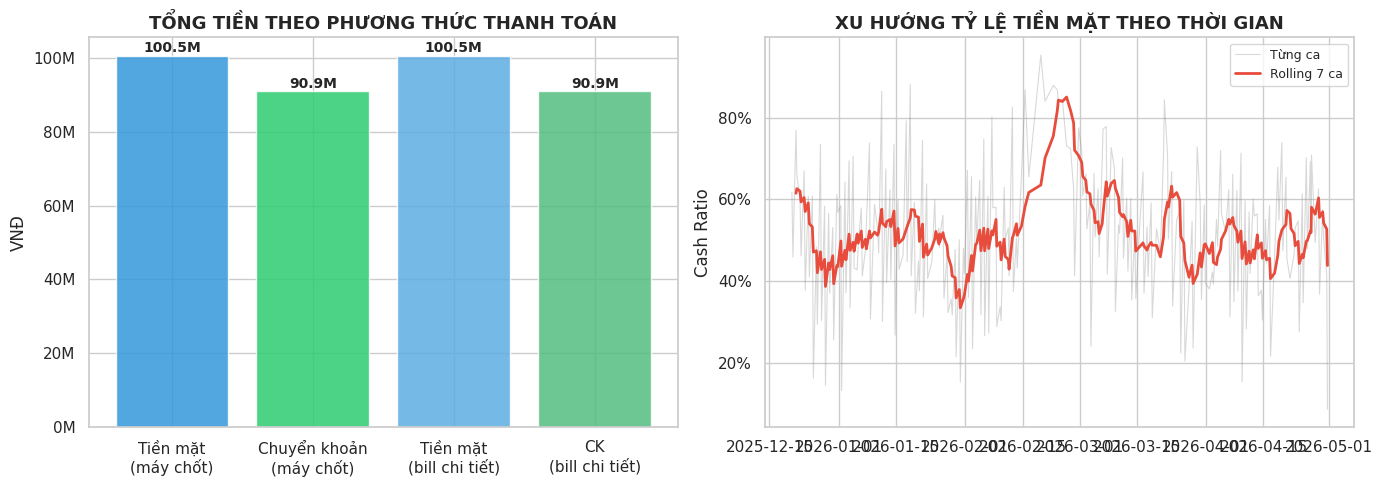

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Tổng tiền mặt vs chuyển khoản ─────────────────────────────────────────
payment_totals = {
    'Tiền mặt\n(máy chốt)':    df_audit['cash_amount'].sum(),
    'Chuyển khoản\n(máy chốt)': df_audit['transfer_amount'].sum(),
    'Tiền mặt\n(bill chi tiết)': df_audit['detail_cash_sum'].sum(),
    'CK\n(bill chi tiết)':       df_audit['detail_transfer_sum'].sum(),
}
ax = axes[0]
bars = ax.bar(payment_totals.keys(), payment_totals.values(),
              color=['#3498db','#2ecc71','#5dade2','#52be80'], alpha=0.85)
for bar, val in zip(bars, payment_totals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200_000,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('TỔNG TIỀN THEO PHƯƠNG THỨC THANH TOÁN')
ax.set_ylabel('VNĐ')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# ── Xu hướng Cash_Ratio theo thời gian ────────────────────────────────────
ax2 = axes[1]
# Rolling 7 ca
rolling = df_audit['Cash_Ratio'].rolling(7, min_periods=3).mean()
ax2.plot(df_audit['timestamp'], df_audit['Cash_Ratio'],
         alpha=0.3, color='gray', linewidth=0.8, label='Từng ca')
ax2.plot(df_audit['timestamp'], rolling,
         color='#e74c3c', linewidth=2, label='Rolling 7 ca')
ax2.set_title('XU HƯỚNG TỶ LỆ TIỀN MẶT THEO THỜI GIAN')
ax2.set_ylabel('Cash Ratio')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Top Ca Bất thường — Danh sách Cảnh báo Đỏ

In [17]:
# Top 10 ca hụt két nặng nhất
top_deficit = (
    df_audit.nsmallest(10, 'Cash_Diff')
    [['timestamp','Shift_Name','total_revenue','bill_count','Cash_Diff','Payment_Mismatch','actual_cash_in_drawer']]
    .copy()
)

# Format dễ đọc
for col in ['total_revenue','Cash_Diff','Payment_Mismatch','actual_cash_in_drawer']:
    top_deficit[col] = top_deficit[col].apply(lambda x: f"{x:>+,.0f} đ" if col != 'total_revenue' else f"{x:,.0f} đ")

print("🚨 TOP 10 CA HỤT KÉT NẶNG NHẤT (Cash_Diff âm nhất):")
display(top_deficit)

🚨 TOP 10 CA HỤT KÉT NẶNG NHẤT (Cash_Diff âm nhất):


,timestamp,Shift_Name,total_revenue,bill_count,Cash_Diff,Payment_Mismatch,actual_cash_in_drawer
6,2025-12-23 11:42:08,Ca Sáng,"830,000 đ",30,"-555,520 đ",+0 đ,+480 đ
2,2025-12-21 11:45:24,Ca Sáng,"544,000 đ",17,"-417,510 đ",+0 đ,+490 đ
5,2025-12-22 17:38:18,Ca Chiều,"843,000 đ",24,"-387,730 đ",+0 đ,"+1,270 đ"
209,2026-04-17 17:31:20,Ca Chiều,"1,871,000 đ",52,"-360,000 đ",+0 đ,"+500,000 đ"
9,2025-12-24 18:28:09,Ca Chiều,"647,000 đ",16,"-263,770 đ",+0 đ,"+1,230 đ"
179,2026-04-01 18:00:10,Ca Chiều,"1,878,000 đ",49,"-215,000 đ",+0 đ,"+500,000 đ"
1,2025-12-20 17:54:52,Ca Chiều,"462,000 đ",16,"-211,140 đ",+0 đ,+860 đ
33,2026-01-05 17:28:05,Ca Chiều,"784,000 đ",24,"-181,000 đ",+0 đ,"+200,000 đ"
40,2026-01-09 17:37:47,Ca Sáng,"1,468,000 đ",42,"-172,000 đ",+0 đ,"+690,000 đ"
110,2026-02-14 17:07:22,Ca Chiều,"1,061,000 đ",25,"-107,000 đ",+0 đ,"+590,000 đ"


In [18]:
# Top 10 ca dư két bất thường (nghi thu nợ cũ / bấm nhầm)
top_surplus = (
    df_audit.nlargest(10, 'Cash_Diff')
    [['timestamp','Shift_Name','total_revenue','bill_count','Cash_Diff','Payment_Mismatch','actual_cash_in_drawer']]
    .copy()
)

for col in ['total_revenue','Cash_Diff','Payment_Mismatch','actual_cash_in_drawer']:
    top_surplus[col] = top_surplus[col].apply(lambda x: f"{x:>+,.0f} đ" if col != 'total_revenue' else f"{x:,.0f} đ")

print("💡 TOP 10 CA DƯ KÉT BẤT THƯỜNG (Cash_Diff dương lớn nhất):")
display(top_surplus)

💡 TOP 10 CA DƯ KÉT BẤT THƯỜNG (Cash_Diff dương lớn nhất):


,timestamp,Shift_Name,total_revenue,bill_count,Cash_Diff,Payment_Mismatch,actual_cash_in_drawer
133,2026-03-05 17:45:56,Ca Chiều,"824,000 đ",23,"+2,272,000 đ",+0 đ,"+2,650,000 đ"
49,2026-01-14 12:02:53,Ca Sáng,"800,000 đ",27,"+2,022,000 đ",+0 đ,"+2,610,000 đ"
194,2026-04-09 18:06:12,Ca Chiều,"476,000 đ",13,"+2,017,000 đ",+0 đ,"+2,090,000 đ"
227,2026-04-26 15:37:56,Ca Chiều,"90,000 đ",3,"+2,003,000 đ",+0 đ,"+2,050,000 đ"
215,2026-04-20 17:37:59,Ca Chiều,"1,038,000 đ",24,"+1,987,000 đ",+0 đ,"+2,460,000 đ"
173,2026-03-28 18:18:20,Ca Chiều,"644,000 đ",15,"+1,978,000 đ",+0 đ,"+2,130,000 đ"
123,2026-02-28 17:23:29,Ca Chiều,"1,078,000 đ",29,"+1,955,000 đ",+0 đ,"+2,790,000 đ"
68,2026-01-24 17:40:32,Ca Chiều,"622,000 đ",19,"+1,937,000 đ",+0 đ,"+2,250,000 đ"
122,2026-02-27 17:30:27,Ca Chiều,"424,000 đ",11,"+1,915,000 đ",+0 đ,"+2,090,000 đ"
90,2026-02-04 11:53:16,Ca Sáng,"760,000 đ",31,"+1,899,000 đ",+0 đ,"+2,390,000 đ"


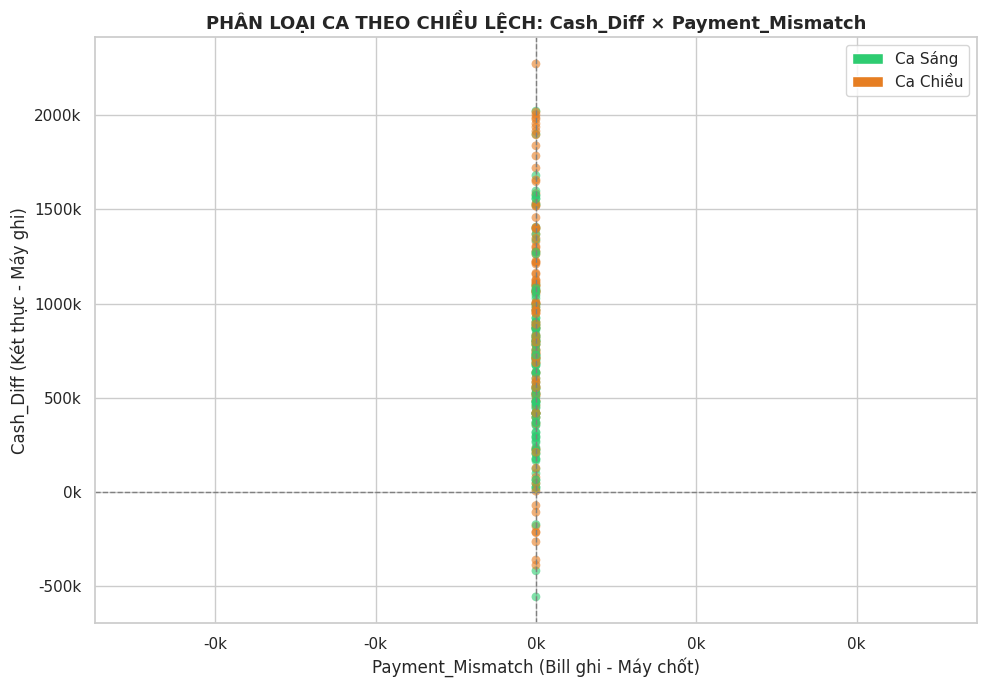

In [19]:
# Scatter: Cash_Diff vs Payment_Mismatch — phân loại tứ phần
fig, ax = plt.subplots(figsize=(10, 7))

colors = df_audit['Shift_Name'].map({'Ca Sáng': '#2ecc71', 'Ca Chiều': '#e67e22'})
scatter = ax.scatter(
    df_audit['Payment_Mismatch'],
    df_audit['Cash_Diff'],
    c=colors, alpha=0.6, s=40, edgecolors='none'
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)

# Nhãn từng tứ phần
for txt, xy in [
    ('Nhầm loại tiền\n(bill→tiền mặt, két→dư)', (150_000, 200_000)),
    ('Thất thoát thực\n(két hụt, bill khớp)', (-200_000, -150_000)),
    ('Nghi thu nợ cũ\n(két dư, bill ổn)', (-200_000, 200_000)),
    ('Bấm nhầm POS\n(két hụt, bill ghi nhiều)', (150_000, -150_000)),
]:
    ax.annotate(txt, xy=xy, fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Payment_Mismatch (Bill ghi - Máy chốt)')
ax.set_ylabel('Cash_Diff (Két thực - Máy ghi)')
ax.set_title('PHÂN LOẠI CA THEO CHIỀU LỆCH: Cash_Diff × Payment_Mismatch', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

from matplotlib.patches import Patch
legend_el = [Patch(facecolor='#2ecc71', label='Ca Sáng'), Patch(facecolor='#e67e22', label='Ca Chiều')]
ax.legend(handles=legend_el)
plt.tight_layout()
plt.show()

**Đọc biểu đồ tứ phần:**

| Góc phần tư | Cash_Diff | Payment_Mismatch | Diễn giải |
|---|---|---|---|
| Trên-phải | `+` | `+` | Bill ghi tiền mặt nhiều hơn máy chốt → nghi **nhầm loại tiền** |
| Dưới-trái | `–` | `–` | Két hụt, bill cũng ít hơn → nghi **thất thoát thực sự** |
| Trên-trái | `+` | `–` | Két dư nhưng bill ổn → nghi **thu nợ cũ không ghi hệ thống** |
| Dưới-phải | `–` | `+` | Két hụt nhưng bill ghi nhiều → nghi **bấm nhầm POS / hoàn tiền** |

---
## 11. Xuất Dữ liệu — Output cho Vòng 2 & 3

In [20]:
import os
os.makedirs('./data', exist_ok=True)

output_path = './data/Audit_Merged_Data.csv'
df_audit.to_csv(output_path, index=False)

print(f"✅ Vòng 1 hoàn tất! Đã xuất {len(df_audit)} ca vào: {output_path}")
print(f"\nCác cột trong df_audit:")
for c in df_audit.columns:
    print(f"  • {c}")

✅ Vòng 1 hoàn tất! Đã xuất 236 ca vào: ./data/Audit_Merged_Data.csv

Các cột trong df_audit:
  • shift_id
  • timestamp
  • total_revenue
  • transfer_amount
  • cash_amount
  • is_morning_shift
  • actual_cash_in_drawer
  • detail_cash_sum
  • detail_transfer_sum
  • detail_revenue_sum
  • bill_count
  • Cash_Diff
  • Payment_Mismatch
  • Revenue_Mismatch
  • Cash_Ratio
  • Shift_Velocity
  • Shift_Name
  • Date


---
## ✅ Tổng kết Vòng 1

### Những gì đã làm:
1. **Ghép dữ liệu** — `DetailsTransaction` → từng ca trong `MainLog` bằng window-based join (`merge_asof` forward direction)
2. **Feature engineering** — `Cash_Diff`, `Payment_Mismatch`, `Revenue_Mismatch`, `Cash_Ratio`, `Shift_Velocity`
3. **EDA** — phân phối sai lệch, so sánh Ca Sáng/Chiều, chuỗi thời gian, heatmap tương quan, scatter tứ phần

### Phát hiện sơ bộ:
- Biểu đồ scatter tứ phần phân loại ca theo **hướng lệch** → cung cấp trực quan cho Vòng 2 (clustering)
- Top ca cảnh báo đỏ đã được liệt kê → đầu vào cho Vòng 4 (rule engine)
- Cột `notes` trong `DetailsTransaction` có 101 giao dịch có ghi chú → xử lý ở **Vòng 3** (Customer Pattern Mining)

### Đầu ra:
- `data/Audit_Merged_Data.csv` — dataset sạch với đầy đủ feature kiểm toán